# Explore eCallisto Processed Data

Quick exploration of .npy spectrogram data from preprocessing team


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
from glob import glob

# Data directory
data_dir = '/Users/remiliascarlet/Desktop/MDP/transfer_learning/burst_data/ecallisto/processed_data/'

# Find all .npy files
npy_files = glob(os.path.join(data_dir, '*.npy'))
print(f"Total .npy files found: {len(npy_files)}")
print(f"\nFirst 5 files:")
for f in npy_files[:5]:
    print(f"  - {os.path.basename(f)}")


Total .npy files found: 160

First 5 files:
  - burst-INDIA-GAURI-04-28-2023-053308.npy
  - burst-NORWAY-EGERSUND-04-17-2023-062329.npy
  - burst-MONGOLIA-UB-07-21-2024-015053.npy
  - burst-ALASKA-ANCHORAGE-03-26-2024-003144.npy
  - burst-USA-ARIZONA-ERAU-12-20-2023-205929.npy


## Load and Inspect Sample Data


In [6]:
# Load first file
sample_file = npy_files[1]
print(f"Loading: {os.path.basename(sample_file)}")

data = np.load(sample_file)

print(f"\nData Structure:")
print(f"  Shape: {data.shape}")
print(f"  Dtype: {data.dtype}")
print(f"  Value range: [{data.min():.3f}, {data.max():.3f}]")
print(f"  Mean: {data.mean():.3f}")
print(f"  Std: {data.std():.3f}")
print(f"  Contains NaN: {np.isnan(data).any()}")
print(f"  Contains Inf: {np.isinf(data).any()}")


Loading: burst-NORWAY-EGERSUND-04-17-2023-062329.npy

Data Structure:
  Shape: (128, 128)
  Dtype: float64
  Value range: [0.000, 254.232]
  Mean: 17.416
  Std: 56.235
  Contains NaN: False
  Contains Inf: False


## Visualize Sample


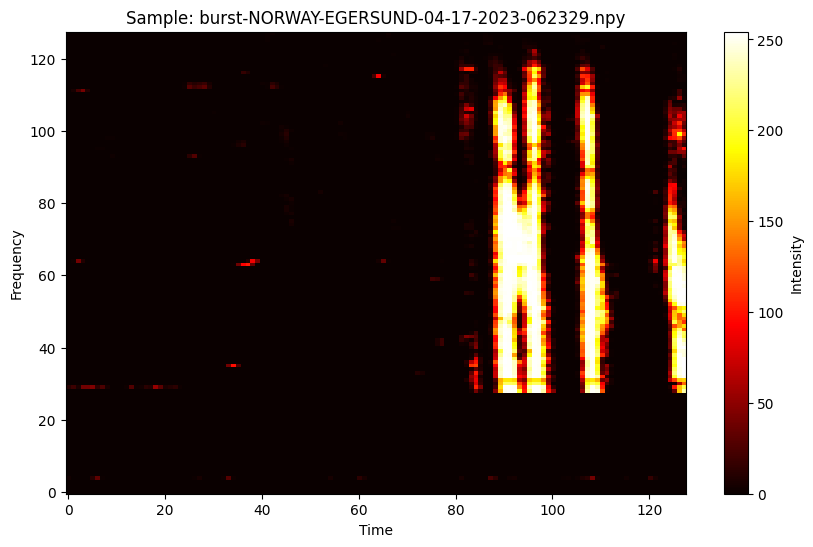

In [7]:
# Visualize the spectrogram
plt.figure(figsize=(10, 6))
plt.imshow(data, aspect='auto', cmap='hot', origin='lower')
plt.colorbar(label='Intensity')
plt.title(f'Sample: {os.path.basename(sample_file)}')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.show()


## Check Multiple Samples


In [ ]:
# Check shapes of multiple files
print("Checking shapes of first 10 files:")
shapes = []
for f in npy_files[:10]:
    data = np.load(f)
    shapes.append(data.shape)
    print(f"  {os.path.basename(f)}: {data.shape}")

# Check if all shapes are consistent
unique_shapes = set(shapes)
print(f"\nUnique shapes found: {unique_shapes}")
print(f"All same shape: {len(unique_shapes) == 1}")


## Analyze File Naming Pattern


In [ ]:
# Extract location information from filenames
locations = {}
for f in npy_files:
    basename = os.path.basename(f)
    # Format: burst-LOCATION-DATE-TIME.npy
    parts = basename.split('-')
    if len(parts) >= 2:
        location = parts[1]  # Second part is location
        locations[location] = locations.get(location, 0) + 1

print("Data by location:")
for loc, count in sorted(locations.items(), key=lambda x: x[1], reverse=True):
    print(f"  {loc}: {count} files ({count/len(npy_files)*100:.1f}%)")


## Visualize Multiple Samples


In [ ]:
# Visualize grid of samples
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, ax in enumerate(axes):
    if idx < len(npy_files):
        data = np.load(npy_files[idx])
        ax.imshow(data, aspect='auto', cmap='hot', origin='lower')
        ax.set_title(os.path.basename(npy_files[idx])[:30], fontsize=8)
        ax.axis('off')

plt.suptitle('Sample eCallisto Processed Burst Data', fontsize=14)
plt.tight_layout()
plt.show()


## Data Summary


In [ ]:
print("="*70)
print("eCallisto Processed Data Summary")
print("="*70)
print(f"\nTotal files: {len(npy_files)}")
print(f"File format: .npy (numpy array)")
print(f"Naming pattern: burst-LOCATION-DATE-TIME.npy")
print(f"\nSample shape: {data.shape}")
print(f"Data type: {data.dtype}")
print(f"Value range: [{data.min():.3f}, {data.max():.3f}]")
print(f"\nLocations: {len(locations)} unique locations")
print(f"Most common: {max(locations, key=locations.get)} ({locations[max(locations, key=locations.get)]} files)")
print("="*70)
